In [1]:
!git clone https://github.com/banlanhat69/Lightweight-Context-Cluster.git
%cd Lightweight-Context-Cluster

Cloning into 'Lightweight-Context-Cluster'...
remote: Enumerating objects: 674, done.
remote: Counting objects: 100% (674/674), done.
remote: Compressing objects: 100% (394/394), done.
remote: Total 674 (delta 441), reused 503 (delta 270), pack-reused 0 (from 0)
Receiving objects: 100% (674/674), 8.19 MiB | 42.34 MiB/s, done.
Resolving deltas: 100% (441/441), done.
/kaggle/working/Lightweight-Context-Cluster


In [2]:
from pathlib import Path
import json, os, subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.environ.get('HBCC_PROJECT_ROOT', '')).expanduser() if os.environ.get('HBCC_PROJECT_ROOT') else None
if PROJECT_ROOT is None or not (PROJECT_ROOT / 'pyproject.toml').is_file():
    candidates = [Path.cwd(), Path.cwd().parent]
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.is_dir(): candidates += list(kaggle_input.iterdir()) + list(kaggle_input.glob('*/*'))
    PROJECT_ROOT = next((p for p in candidates if (p / 'pyproject.toml').is_file() and (p / 'tools' / 'run_food101_experiments.py').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Không tìm thấy source repo. Hãy đặt biến môi trường HBCC_PROJECT_ROOT hoặc sửa PROJECT_ROOT trong cell này.')
PROJECT_ROOT = PROJECT_ROOT.resolve()
IS_KAGGLE = Path('/kaggle/working').is_dir()
DATA_ROOT = Path('/kaggle/working/torchvision_data') if IS_KAGGLE else PROJECT_ROOT / 'data' / 'food101'
OUTPUT_ROOT = Path('/kaggle/working/food101_runs') if IS_KAGGLE else PROJECT_ROOT / 'runs' / 'food101'
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_ROOT   :', DATA_ROOT)
print('OUTPUT_ROOT :', OUTPUT_ROOT)


PROJECT_ROOT: /kaggle/working/Lightweight-Context-Cluster
DATA_ROOT   : /kaggle/working/torchvision_data
OUTPUT_ROOT : /kaggle/working/food101_runs


In [3]:
# Tổng 200 epoch, chia thành hai phiên 100 epoch.
MODELS = ['hbcc']
PHASE = 2  # Phiên đầu: 1. Phiên tiếp theo từ checkpoint: 2.
EPOCHS_PER_PHASE = 100
TOTAL_EPOCHS = 200
RUN_UNTIL_EPOCH = min(PHASE * EPOCHS_PER_PHASE, TOTAL_EPOCHS)
DEVICE = 'auto'

# Để None nếu train mới. Khi resume, ưu tiên latest.pth (không dùng best.pth).
# PHASE=1: thường để cả hai là None. PHASE=2: trỏ tới latest.pth sau epoch 100.
# Ví dụ: Path('/kaggle/input/food101-checkpoints/hbcc/latest.pth')
RESUME_CHECKPOINTS = {
    'hbcc': '/kaggle/input/models/hoangnamphuc/food-hbcc100e/pytorch/default/1/latest.pth',
    'resnet18': None,
}
SMOKE_TEST = False  # True: chỉ chạy 2 batch mỗi split trong 1 epoch

sys.path.insert(0, str(PROJECT_ROOT))
from lightweight_hbcc.models import build_model
from lightweight_hbcc.models.food101 import HBCC_FOOD101_BEST100_CONFIG
from lightweight_hbcc.config import load_config

hbcc = build_model({'model': {'name': 'hbcc_food101_best100', 'num_classes': 101}})
resnet = build_model({'model': {'name': 'resnet18_224', 'num_classes': 101}})
print('HBCC parameters    :', f'{sum(p.numel() for p in hbcc.parameters()):,}')
print('ResNet-18 parameters:', f'{sum(p.numel() for p in resnet.parameters()):,}')
print('HBCC canonical config:')
display(pd.Series(HBCC_FOOD101_BEST100_CONFIG, name='value').to_frame())
hbcc_recipe = load_config(PROJECT_ROOT / 'configs' / 'food101' / 'hbcc_best100.yaml')
resnet_recipe = load_config(PROJECT_ROOT / 'configs' / 'food101' / 'resnet18_best100.yaml')
display(pd.DataFrame({'hbcc': hbcc_recipe['train'], 'resnet18': resnet_recipe['train']}))
unknown_resume_models = set(RESUME_CHECKPOINTS) - {'hbcc', 'resnet18'}
if PHASE not in {1, 2}:
    raise ValueError('PHASE phải là 1 hoặc 2.')
if TOTAL_EPOCHS != 2 * EPOCHS_PER_PHASE:
    raise ValueError('Thiết lập này yêu cầu tổng epoch bằng đúng hai phiên.')
if unknown_resume_models:
    raise KeyError(f'Khóa resume không hợp lệ: {sorted(unknown_resume_models)}')
if SMOKE_TEST and any(RESUME_CHECKPOINTS.values()):
    raise ValueError('Không dùng SMOKE_TEST khi resume vì nó thay đổi tổng epoch budget.')
for model_key, checkpoint in RESUME_CHECKPOINTS.items():
    if checkpoint is not None and model_key not in MODELS:
        raise ValueError(f'{model_key} có checkpoint resume nhưng không nằm trong MODELS.')
    if checkpoint is not None and not Path(checkpoint).expanduser().is_file():
        raise FileNotFoundError(f'Không tìm thấy checkpoint resume cho {model_key}: {checkpoint}')
if PHASE == 2:
    missing_resume = [model for model in MODELS if RESUME_CHECKPOINTS.get(model) is None]
    if missing_resume:
        raise ValueError(f'PHASE=2 cần latest.pth cho: {missing_resume}')
print(f'PHASE={PHASE}: sẽ chạy đến epoch {RUN_UNTIL_EPOCH}/{TOTAL_EPOCHS}')
del hbcc, resnet


HBCC parameters    : 2,566,391
ResNet-18 parameters: 11,228,325
HBCC canonical config:


,value
use_coord,True
embed_dims,"[48, 80, 160, 256]"
depths,"[2, 2, 3, 2]"
mlp_ratios,"[3.0, 3.0, 3.0, 3.0]"
heads,"[2, 2, 5, 6]"
head_dim,"[12, 20, 32, 32]"
proposals,"[[2, 2], [2, 2], [2, 2], [2, 2]]"
folds,"[[8, 8], [4, 4], [2, 2], [1, 1]]"
similarities,"[cosine, cosine, cosine, cosine]"
assignment_modes,"[hard, hard, hard, hard]"


,hbcc,resnet18
seed,42,42
deterministic,False,False
epochs,200,200
warmup_epochs,5,5
amp,True,True
kd_method,none,none
kd_alpha,0.0,0.0
skip_test,False,False
optimizer,adamw,sgd
lr,0.0008,0.0125


PHASE=2: sẽ chạy đến epoch 200/200


In [4]:
runner = PROJECT_ROOT / 'tools' / 'run_food101_experiments.py'
effective_total_epochs = 1 if SMOKE_TEST else TOTAL_EPOCHS
effective_run_until = 1 if SMOKE_TEST else RUN_UNTIL_EPOCH
command = [sys.executable, str(runner), '--models', *MODELS, '--output', str(OUTPUT_ROOT), '--data-root', str(DATA_ROOT), '--epochs', str(effective_total_epochs), '--run-until-epoch', str(effective_run_until), '--device', DEVICE, '--no-progress']
for model_key, flag in {'hbcc': '--resume-hbcc', 'resnet18': '--resume-resnet18'}.items():
    checkpoint = RESUME_CHECKPOINTS.get(model_key)
    if checkpoint is not None:
        command += [flag, str(Path(checkpoint).expanduser().resolve())]
if SMOKE_TEST:
    command += ['--limit-train-batches', '2', '--limit-val-batches', '2', '--limit-test-batches', '2']
print('Running:', ' '.join(command))
subprocess.run(command, cwd=PROJECT_ROOT, check=True)


Running: /usr/bin/python3 /kaggle/working/Lightweight-Context-Cluster/tools/run_food101_experiments.py --models hbcc --output /kaggle/working/food101_runs --data-root /kaggle/working/torchvision_data --epochs 200 --run-until-epoch 200 --device auto --no-progress --resume-hbcc /kaggle/input/models/hoangnamphuc/food-hbcc100e/pytorch/default/1/latest.pth

=== Running hbcc: /usr/bin/python3 /kaggle/working/Lightweight-Context-Cluster/tools/train.py --config /kaggle/working/Lightweight-Context-Cluster/configs/food101/hbcc_best100.yaml --output /kaggle/working/food101_runs --device auto --run-until-epoch 200 --print-every 1 --override data.root=/kaggle/working/torchvision_data --override train.epochs=200 --override train.mixup_cutmix_off_epoch=185 --no-progress --resume /kaggle/input/models/hoangnamphuc/food-hbcc100e/pytorch/default/1/latest.pth ===
setup: dataset=food101 output=/kaggle/working/food101_runs/food101_hbcc_2p5m_2x100_seed42 device=cuda seed=42 loader_seed=42 deterministic=False

100%|██████████| 5.00G/5.00G [02:09<00:00, 38.7MB/s]


setup: data ready train_samples=68175 train_batches=2130 val_samples=7575 val_batches=119 test_enabled=True elapsed=190.1s
setup: building model...
setup: model ready params=2566391 trainable_params=2562935 elapsed=190.5s
setup: HBCC feature shapes=[(56, 56), (28, 28), (14, 14), (7, 7)]
setup: validating resume checkpoint /kaggle/input/models/hoangnamphuc/food-hbcc100e/pytorch/default/1/latest.pth
setup: optimizer=adamw
resume: completed_epochs=100 next_epoch=101 best_epoch=98 best_val_acc1=73.77
train: starting epoch=101 run_until_epoch=200 total_epochs=200 skip_test=False
epoch=100 lr=0.000410153 train_acc1=64.12 train_loss=1.8057 val_acc1=73.61 val_loss=1.0404 val_acc5=90.39 ce=1.8057 cluster_balance=0.0000 cluster_balance_weighted=0.0000
epoch=101 lr=0.000403718 train_acc1=63.57 train_loss=1.8262 val_acc1=74.55 val_loss=1.0145 val_acc5=90.93 ce=1.8262 cluster_balance=0.0000 cluster_balance_weighted=0.0000
epoch=102 lr=0.000397282 train_acc1=64.16 train_loss=1.7988 val_acc1=73.94 va

CompletedProcess(args=['/usr/bin/python3', '/kaggle/working/Lightweight-Context-Cluster/tools/run_food101_experiments.py', '--models', 'hbcc', '--output', '/kaggle/working/food101_runs', '--data-root', '/kaggle/working/torchvision_data', '--epochs', '200', '--run-until-epoch', '200', '--device', 'auto', '--no-progress', '--resume-hbcc', '/kaggle/input/models/hoangnamphuc/food-hbcc100e/pytorch/default/1/latest.pth'], returncode=0)

## Kết quả
Phiên 1 chỉ tạo `progress.csv` và tuyệt đối chưa đọc test set. Sau phiên 2, `comparison.csv` dùng checkpoint có validation accuracy tốt nhất; test accuracy không được dùng để chọn model hay epoch.

In [5]:
run_names = {'hbcc': 'food101_hbcc_2p5m_2x100_seed42', 'resnet18': 'food101_resnet18_scratch_2x100_seed42'}
histories = []
for model_key in MODELS:
    metrics_path = OUTPUT_ROOT / run_names[model_key] / 'metrics.jsonl'
    records = [json.loads(line) for line in metrics_path.read_text(encoding='utf-8').splitlines() if line.strip()]
    frame = pd.DataFrame([row for row in records if 'val_acc1' in row])
    frame['model'] = model_key
    frame['epoch_display'] = frame['epoch'] + 1
    histories.append(frame)
history = pd.concat(histories, ignore_index=True)
summary_name = 'comparison.csv' if effective_run_until == effective_total_epochs else 'progress.csv'
summary = pd.read_csv(OUTPUT_ROOT / summary_name)
if summary_name == 'comparison.csv':
    summary = summary.sort_values('test_acc1', ascending=False)
display(summary)


,model,optimizer,parameters,status,completed_epochs,best_epoch,best_val_acc1,best_val_acc5,test_acc1,test_acc5,test_loss,run_dir
0,hbcc,adamw,2566391,complete,200,199,77.676568,92.013201,82.530693,95.334653,0.669988,/kaggle/working/food101_runs/food101_hbcc_2p5m...


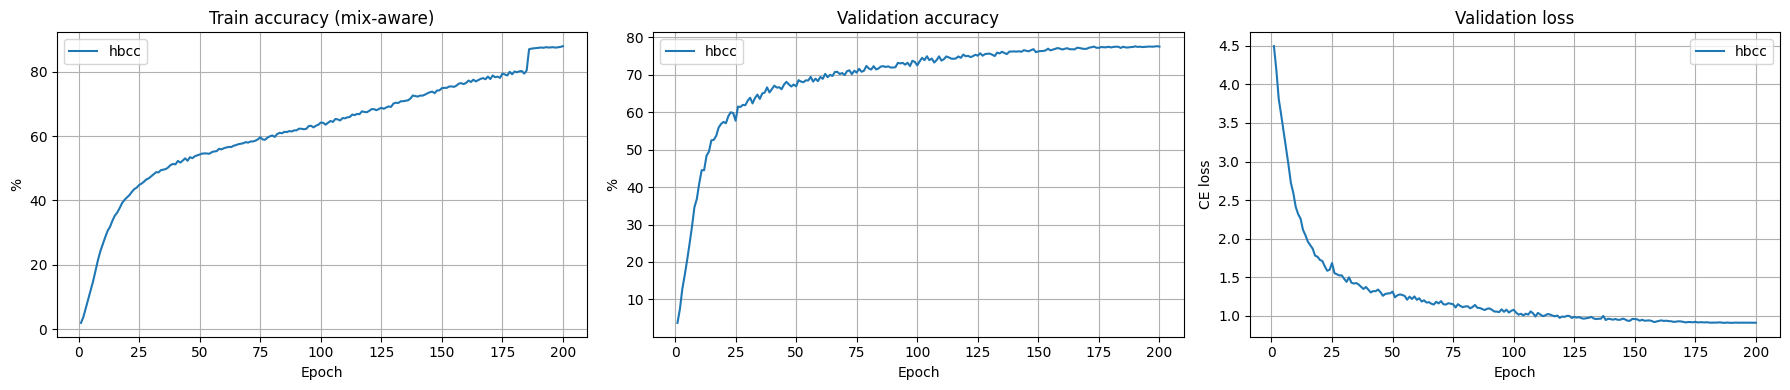

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for model_key, group in history.groupby('model'):
    axes[0].plot(group.epoch_display, group.train_acc1, label=model_key)
    axes[1].plot(group.epoch_display, group.val_acc1, label=model_key)
    axes[2].plot(group.epoch_display, group.val_loss, label=model_key)
axes[0].set_title('Train accuracy (mix-aware)'); axes[1].set_title('Validation accuracy'); axes[2].set_title('Validation loss')
for axis in axes:
    axis.set_xlabel('Epoch'); axis.grid(True); axis.legend()
axes[0].set_ylabel('%'); axes[1].set_ylabel('%'); axes[2].set_ylabel('CE loss')
plt.tight_layout(); plt.show()


In [7]:
# Tải nhanh last checkpoint (pipeline lưu với tên latest.pth).
from IPython.display import FileLink, Markdown, display

checkpoint_run_names = {
    'hbcc': 'food101_hbcc_2p5m_2x100_seed42',
    'resnet18': 'food101_resnet18_scratch_2x100_seed42',
}
latest_checkpoints = {
    model: (OUTPUT_ROOT / run_name / 'latest.pth').resolve()
    for model, run_name in checkpoint_run_names.items()
    if model in MODELS
}
missing = {model: path for model, path in latest_checkpoints.items() if not path.is_file()}
if missing:
    raise FileNotFoundError('Checkpoint chưa tồn tại: ' + ', '.join(f'{model}={path}' for model, path in missing.items()))
for model, checkpoint_path in latest_checkpoints.items():
    link_path = Path(os.path.relpath(checkpoint_path, Path.cwd()))
    display(Markdown(f'**{model.upper()} — latest.pth**'))
    display(FileLink(str(link_path), result_html_prefix='Tải checkpoint: '))


**HBCC — latest.pth**

/kaggle/working/food101_runs/food101_hbcc_2p5m_2x100_seed42/latest.pth